# Turismo + Vivienda en Bogotá — expansión de la vivienda turística

**DataJam Bogotá 2026 — Edición 4**

## Pregunta analítica

> ¿En qué localidades de Bogotá se concentra y ha crecido más la vivienda turística tipo Airbnb, qué tanto de ese crecimiento ocurre por fuera de las Zonas de Interés Turístico (ZIT) definidas por el POT, y qué relación tiene con la disponibilidad de vivienda residencial, el avalúo catastral y la presencia de infraestructura turística formal?

Formulada con el método del taller guiado (`pautas y contexto/01.taller_datajam_bogota_problema_publico.pdf`):

| Paso | Definición |
|---|---|
| **Territorio** | Bogotá, las 20 localidades, con foco en el corredor centro-norte (Chapinero, Usaquén, Santa Fe, Teusaquillo, Barrios Unidos) |
| **Fenómeno** | Expansión y dispersión geográfica de la vivienda turística (alojamiento tipo Airbnb, RNT) |
| **Pregunta** | Ver arriba |
| **Hipótesis** | H1 a H6, ver secciones abajo |
| **Variables** | vivienda turística (dependiente), pertenencia a ZIT / stock de vivienda / avalúo catastral / infraestructura turística formal (explicativas) |

## Hipótesis de trabajo

| # | Hipótesis |
|---|---|
| **H1** | El crecimiento de vivienda turística (2023 → actual) es desigual entre localidades, concentrado en el corredor centro-norte |
| **H2** | Una proporción relevante de la vivienda turística se ubica fuera de las Zonas de Interés Turístico (ZIT) oficiales |
| **H3** | En las localidades más afectadas, la vivienda turística ya representa una fracción no trivial y **creciente** del stock de vivienda residencial |
| **H4** | Las localidades con más vivienda turística muestran un avalúo catastral por m² más alto |
| **H5** | La vivienda turística coincide espacialmente con alojamiento formal y gastronomía/bar, formando un clúster reconocible de economía turística |
| **H6** | Al bajar de localidad a sector catastral (unidad más fina), aparecen perfiles de sector diferenciados (no solo un gradiente centro-periferia) que un mapa auto-organizado (SOM) puede identificar sin supervisión |


## Índice de fuentes de datos

Todas del [Portal de Datos Abiertos de Bogotá](https://datosabiertos.bogota.gov.co/) (catálogo CKAN). Para cada una se indica la página del dataset (para verificar/explorar manualmente) y el recurso exacto que se descarga (siempre **GeoJSON** u **ODS/XLSX** — se prefieren sobre SHP/GPKG/KML/DXF porque se leen sin dependencias GIS pesadas tipo GDAL/fiona, y sobre los servicios Esri REST/WMS/WFS porque esos son servicios en vivo, no archivos reproducibles).

| # | Dataset | Entidad | Página del dataset | Recurso descargado |
|---|---|---|---|---|
| D1 | Vivienda Turística Bogotá | Instituto Distrital de Turismo (IDT) | [`vivienda-turistica-bogota`](https://datosabiertos.bogota.gov.co/dataset/vivienda-turistica-bogota) | GeoJSON actual + GeoJSON versión 2023 |
| D2 | Zonas de Interés Turístico (ZIT) | IDT / POT | [`zonas-interes-turistico-bogota-d-c`](https://datosabiertos.bogota.gov.co/dataset/zonas-interes-turistico-bogota-d-c) | GeoJSON actual |
| D3 | Proyecciones de Hogares y Viviendas 2018-2035 | Secretaría Distrital de Planeación (SDP) / Catastro | [`proyecciones-de-hogares-y-viviendas-2018-2035`](https://datosabiertos.bogota.gov.co/dataset/proyecciones-de-hogares-y-viviendas-2018-2035) | ODS "por Localidad", hoja `Proy_Viviendas_Totales_Loc` |
| D5 | Localidad Bogotá D.C. (límites) | Catastro Bogotá | [`localidad-bogota-d-c`](https://datosabiertos.bogota.gov.co/dataset/localidad-bogota-d-c) | JSON (formato Esri, no GeoJSON estándar — ver nota abajo) |
| D6 | Mediana avalúo catastral por m² en PH por manzana | Catastro Bogotá | [`med-aval-cat-ph-mz-bogota-d-c`](https://datosabiertos.bogota.gov.co/dataset/med-aval-cat-ph-mz-bogota-d-c) | GeoJSON versión actual (2026) |
| D7 | Establecimiento de Alojamiento Turístico | IDT | [`establecimiento-de-alojamiento-turistico-bogota`](https://datosabiertos.bogota.gov.co/dataset/establecimiento-de-alojamiento-turistico-bogota) | GeoJSON actual |
| D8 | Establecimiento de Gastronomía y Bar | IDT | [`establecimiento-de-gastronomia-y-bar-bogota`](https://datosabiertos.bogota.gov.co/dataset/establecimiento-de-gastronomia-y-bar-bogota) | GeoJSON actual |

**Notas de calidad de datos** (para documentar también en la nota técnica de entrega):
- El archivo de D5 se anuncia como "GeoJSON" en el portal pero internamente viene en formato Esri JSON (`attributes` / `geometry.rings`), no en GeoJSON estándar (`properties` / `geometry.coordinates`). Se detectó y se manejó aparte (ver función `cargar_localidades`).
- D5 nombra "Candelaria" a la localidad que el resto de fuentes (D1, D3, D7, D8) llaman "La Candelaria" — inconsistencia de nomenclatura entre fuentes del mismo Distrito. Se resolvió normalizando el nombre (ver función `normalizar`).


In [1]:
import json
import unicodedata
import urllib.request
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import shape, Point, Polygon

sns.set_style("whitegrid")

RAW = Path("../data/raw/turismo_vivienda")
PROCESSED = Path("../data/processed")
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

## Descarga reproducible

Cada archivo se descarga solo si no existe localmente (`data/raw/turismo_vivienda/`), directamente desde el recurso del portal indicado en el índice de fuentes. Así el notebook corre de punta a punta en un checkout limpio del repositorio.

In [2]:
DATASETS = {
    "vivienda_turistica_actual.geojson": "https://datosabiertos.bogota.gov.co/dataset/5ca17e43-4026-454b-924e-b52164f85f89/resource/8cd9cdc5-0560-4fd6-8ef5-d04086af9dcb/download/vtur.geojson",
    "vivienda_turistica_2023.geojson": "https://datosabiertos.bogota.gov.co/dataset/5ca17e43-4026-454b-924e-b52164f85f89/resource/f86c0ad8-177a-43d2-944e-675d8f9a4e72/download/vtur2.geojson",
    "zit_actual.geojson": "https://datosabiertos.bogota.gov.co/dataset/0f36f844-5c2e-4e31-8486-d698a0a3f3dd/resource/7ba503d4-cee5-417b-b96c-4198efcb6421/download/zitu.geojson",
    "hogares_viviendas_localidad_2018_2035.ods": "https://datosabiertos.bogota.gov.co/dataset/2e5d5c9f-ead3-4a83-baa9-63272606297c/resource/7271be96-46d7-4932-88ab-3bf793d248e0/download/202503_localidad_proyeccion_hogares_viviendas_2018_2035.ods",
    "localidades_bogota.geojson": "https://datosabiertos.bogota.gov.co/dataset/856cb657-8ca3-4ee8-857f-37211173b1f8/resource/497b8756-0927-4aee-8da9-ca4e32ca3a8a/download/loca.json",
    "avaluo_catastral_ph_manzana_actual.geojson": "https://datosabiertos.bogota.gov.co/dataset/18ac8fb7-d72a-4d00-aad5-dda71b7adf0a/resource/17cf42c2-6971-4e41-a1a8-38ffe0d24a7a/download/medavalcat_mz_ph_2026.geojson",
    "alojamiento_turistico_actual.geojson": "https://datosabiertos.bogota.gov.co/dataset/316f1588-c5f3-4dc9-b91c-55d82c2e0d75/resource/cbb4c7f6-80d4-44d4-9835-159b793c0afa/download/eatu.geojson",
    "gastronomia_bar_actual.geojson": "https://datosabiertos.bogota.gov.co/dataset/f0a98681-ba40-4a6b-8542-32948e02f4a2/resource/ce4ae41c-dacf-4405-9cb2-a78c43d8f139/download/egba.geojson",
}


def download_if_missing(filename: str) -> Path:
    dest = RAW / filename
    if not dest.exists():
        url = DATASETS[filename]
        print(f"Descargando {filename} ...")
        urllib.request.urlretrieve(url, dest)
    return dest


for fname in DATASETS:
    path = download_if_missing(fname)
    print(f"{fname:<48} {path.stat().st_size / 1024:>10,.0f} KB")

vivienda_turistica_actual.geojson                     2,395 KB
vivienda_turistica_2023.geojson                       1,373 KB
zit_actual.geojson                                       98 KB
hogares_viviendas_localidad_2018_2035.ods                93 KB
localidades_bogota.geojson                            2,308 KB
avaluo_catastral_ph_manzana_actual.geojson           65,794 KB
alojamiento_turistico_actual.geojson                    261 KB
gastronomia_bar_actual.geojson                           55 KB


## Funciones auxiliares

- `fix_mojibake`: varios datasets de Bogotá exportan texto UTF-8 mal decodificado como Latin-1 (aparece como `Ã±`). Se corrige re-codificando.
- `normalizar`: quita tildes y pasa a mayúsculas, para poder cruzar nombres de localidad entre datasets que los escriben distinto (`Usaquén` vs `USAQUEN`).
- `cargar_localidades`: cada localidad como polígono de `shapely`, para asignar por contención (point-in-polygon) a los datasets que no traen el nombre de localidad directo.
- `LOC_CODE_TO_NAME`: los datasets de vivienda turística/alojamiento/gastronomía traen la localidad como **código numérico** (1-20), no como texto. Este es el mapeo oficial de códigos de localidad de Bogotá.

In [3]:
def fix_mojibake(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def normalizar(s):
    s = "".join(
        c for c in unicodedata.normalize("NFKD", str(s)) if not unicodedata.combining(c)
    ).upper().strip()
    # D5 (límites de localidad) llama "CANDELARIA" a lo que otras fuentes llaman "La Candelaria"
    if s.startswith("LA "):
        s = s[3:]
    return s


LOC_CODE_TO_NAME = {
    1: "Usaquén", 2: "Chapinero", 3: "Santa Fe", 4: "San Cristóbal", 5: "Usme",
    6: "Tunjuelito", 7: "Bosa", 8: "Kennedy", 9: "Fontibón", 10: "Engativá",
    11: "Suba", 12: "Barrios Unidos", 13: "Teusaquillo", 14: "Los Mártires",
    15: "Antonio Nariño", 16: "Puente Aranda", 17: "La Candelaria",
    18: "Rafael Uribe Uribe", 19: "Ciudad Bolívar", 20: "Sumapaz",
}


def cargar_localidades(path):
    # D5 viene en formato Esri JSON (attributes/geometry.rings), no GeoJSON estándar.
    data = json.load(open(path, encoding="utf-8"))
    polys = []
    for feat in data["features"]:
        nombre = fix_mojibake(feat["attributes"]["LocNombre"])
        rings = feat["geometry"]["rings"]
        poly = Polygon(rings[0], holes=rings[1:] if len(rings) > 1 else None).buffer(0)
        polys.append((nombre, poly))
    return polys


def asignar_localidad(punto, localidad_polys):
    for nombre, poly in localidad_polys:
        if poly.contains(punto):
            return nombre
    return None


def contar_por_codigo_localidad(path, campo):
    data = json.load(open(path, encoding="utf-8"))
    codigos = [
        int(f["properties"][campo])
        for f in data["features"]
        if f["properties"].get(campo) not in (None, "")
    ]
    conteo = pd.Series(codigos).value_counts()
    conteo.index = conteo.index.map(LOC_CODE_TO_NAME)
    return conteo


localidad_polys = cargar_localidades(RAW / "localidades_bogota.geojson")
print(f"Localidades cargadas: {len(localidad_polys)}")

Localidades cargadas: 20


## H1 — Crecimiento y concentración geográfica

**Fuente:** D1 (`vivienda_turistica_2023.geojson`, `vivienda_turistica_actual.geojson`). Cada punto trae el código de localidad directo en la propiedad `Localidad`/`LOCALIDAD` — no requiere cruce espacial.

In [4]:
vt_2023 = contar_por_codigo_localidad(RAW / "vivienda_turistica_2023.geojson", "Localidad").rename("vt_2023")
vt_actual = contar_por_codigo_localidad(RAW / "vivienda_turistica_actual.geojson", "LOCALIDAD").rename("vt_actual")

h1 = pd.concat([vt_2023, vt_actual], axis=1).fillna(0).astype(int)
h1["crecimiento_abs"] = h1["vt_actual"] - h1["vt_2023"]
h1["crecimiento_pct"] = ((h1["vt_actual"] - h1["vt_2023"]) / h1["vt_2023"].replace(0, pd.NA) * 100).round(1)
h1 = h1.sort_values("vt_actual", ascending=False)

total_2023, total_actual = h1["vt_2023"].sum(), h1["vt_actual"].sum()
print(f"Total ciudad: {total_2023} (2023) -> {total_actual} (actual)  |  crecimiento {total_actual/total_2023*100 - 100:.1f}%")
h1

Total ciudad: 4273 (2023) -> 7529 (actual)  |  crecimiento 76.2%


,vt_2023,vt_actual,crecimiento_abs,crecimiento_pct
Chapinero,1128,2454,1326,117.6
Usaquén,837,1370,533,63.7
Santa Fe,521,863,342,65.6
Teusaquillo,423,756,333,78.7
Barrios Unidos,274,504,230,83.9
Suba,322,380,58,18.0
Engativá,225,357,132,58.7
Fontibón,187,309,122,65.2
La Candelaria,154,221,67,43.5
Kennedy,82,94,12,14.6


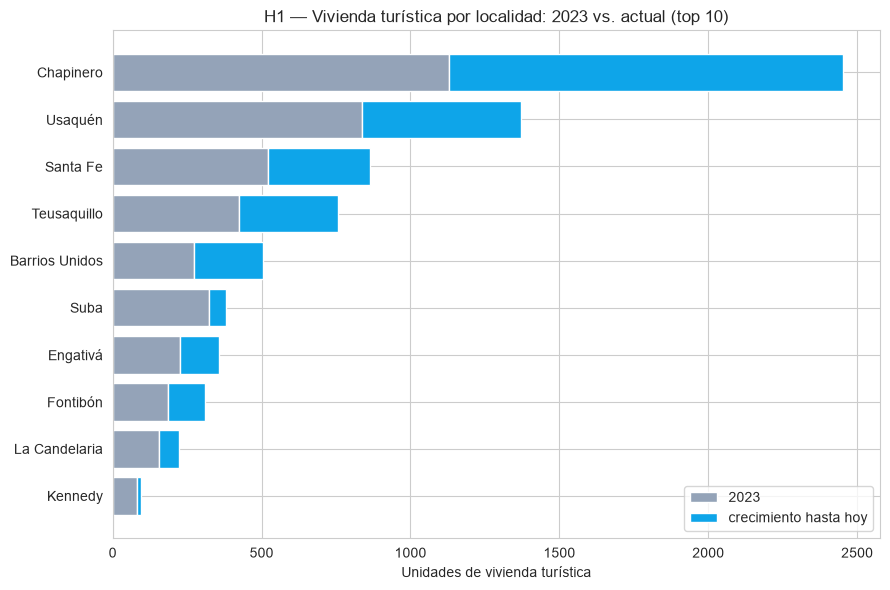

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
top10 = h1.head(10).sort_values("vt_actual")
ax.barh(top10.index, top10["vt_2023"], color="#94a3b8", label="2023")
ax.barh(top10.index, top10["vt_actual"] - top10["vt_2023"], left=top10["vt_2023"], color="#0ea5e9", label="crecimiento hasta hoy")
ax.set_xlabel("Unidades de vivienda turística")
ax.set_title("H1 — Vivienda turística por localidad: 2023 vs. actual (top 10)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/h1_crecimiento_vivienda_turistica.png", dpi=150)
plt.show()

## H2 — Relación con las Zonas de Interés Turístico (ZIT)

**Fuentes:** D1 + D2 (`zit_actual.geojson`). D2 no trae el nombre de localidad por punto de vivienda turística — se hace cruce espacial *point-in-polygon* con `shapely`, usando la geometría nativa de cada archivo (ambos vienen en la misma proyección, Web Mercator / EPSG:3857 — **no** se deben mezclar con las coordenadas en grados de `LATITUD`/`LONGITUD` de las propiedades, que están en otro sistema).

In [6]:
zit_data = json.load(open(RAW / "zit_actual.geojson", encoding="utf-8"))
zit_polys = [shape(f["geometry"]) for f in zit_data["features"]]


def pct_dentro_zit(path):
    data = json.load(open(path, encoding="utf-8"))
    dentro = fuera = 0
    for f in data["features"]:
        punto = shape(f["geometry"])
        if any(poly.contains(punto) for poly in zit_polys):
            dentro += 1
        else:
            fuera += 1
    total = dentro + fuera
    return dentro, fuera, total


h2_rows = []
for etiqueta, fname in [("2023", "vivienda_turistica_2023.geojson"), ("actual", "vivienda_turistica_actual.geojson")]:
    dentro, fuera, total = pct_dentro_zit(RAW / fname)
    h2_rows.append({
        "corte": etiqueta, "total": total, "dentro_zit": dentro, "fuera_zit": fuera,
        "pct_dentro_zit": round(dentro / total * 100, 1), "pct_fuera_zit": round(fuera / total * 100, 1),
    })

h2 = pd.DataFrame(h2_rows)
h2

,corte,total,dentro_zit,fuera_zit,pct_dentro_zit,pct_fuera_zit
0,2023,4273,1661,2612,38.9,61.1
1,actual,7529,3362,4167,44.7,55.3


**Lectura honesta:** más de la mitad de la vivienda turística sigue estando fuera de toda ZIT oficial (55.3% hoy), lo cual sostiene la hipótesis en sentido estricto. Pero la *tendencia* es la contraria a lo esperado: la proporción fuera de ZIT **bajó** de 61.1% (2023) a 55.3% (actual) — el crecimiento reciente se concentró proporcionalmente más *dentro* de las zonas ya planeadas para turismo (coincide con que Chapinero, el mayor motor del crecimiento en H1, tiene varias ZIT grandes). No se puede afirmar "desborde creciente" con estos dos cortes; sí se sostiene "la mayoría ocurre fuera de la planeación oficial", que ya es un hallazgo relevante por sí solo.

## H3 — Peso sobre el stock de vivienda residencial

**Fuentes:** D1 + D3 (`hogares_viviendas_localidad_2018_2035.ods`, hoja `Proy_Viviendas_Totales_Loc`). El archivo trae encabezados en la fila 7 (no la fila 0) y columnas de años — hay que ubicarlas manualmente.

In [7]:
viv_raw = pd.read_excel(RAW / "hogares_viviendas_localidad_2018_2035.ods", engine="odf",
                         sheet_name="Proy_Viviendas_Totales_Loc", header=None)
años = viv_raw.iloc[7]
datos = viv_raw.iloc[8:28].copy()
datos.columns = list(viv_raw.iloc[6, :6]) + list(años[6:])
viviendas = datos[["Nombre Localidad", 2023.0, 2025.0]].dropna()
viviendas.columns = ["localidad", "viviendas_2023", "viviendas_2025"]
viviendas["localidad"] = viviendas["localidad"].apply(fix_mojibake)
viviendas["key"] = viviendas["localidad"].apply(normalizar)
viviendas = viviendas.set_index("key")

vt_2023_k = vt_2023.copy(); vt_2023_k.index = vt_2023_k.index.map(normalizar)
vt_actual_k = vt_actual.copy(); vt_actual_k.index = vt_actual_k.index.map(normalizar)

h3 = viviendas.join(vt_2023_k.rename("vt_2023")).join(vt_actual_k.rename("vt_actual")).fillna(0)
h3["pct_2023"] = (h3["vt_2023"] / h3["viviendas_2023"] * 100).round(3)
h3["pct_2025"] = (h3["vt_actual"] / h3["viviendas_2025"] * 100).round(3)
h3 = h3.sort_values("pct_2025", ascending=False)
h3[["localidad", "viviendas_2023", "vt_2023", "pct_2023", "viviendas_2025", "vt_actual", "pct_2025"]].head(8)

,localidad,viviendas_2023,vt_2023,pct_2023,viviendas_2025,vt_actual,pct_2025
key,,,,,,,
CHAPINERO,Chapinero,91719.0,1128.0,1.230,93702.0,2454.0,2.619
CANDELARIA,La Candelaria,9197.0,154.0,1.674,9375.0,221.0,2.357
SANTA FE,Santa Fe,51691.0,521.0,1.008,54122.0,863.0,1.595
TEUSAQUILLO,Teusaquillo,76641.0,423.0,0.552,79194.0,756.0,0.955
BARRIOS UNIDOS,Barrios Unidos,59579.0,274.0,0.460,61249.0,504.0,0.823
USAQUEN,Usaquén,246960.0,837.0,0.339,255192.0,1370.0,0.537
LOS MARTIRES,Los Mártires,36543.0,39.0,0.107,37631.0,76.0,0.202
FONTIBON,Fontibón,149214.0,187.0,0.125,154498.0,309.0,0.200


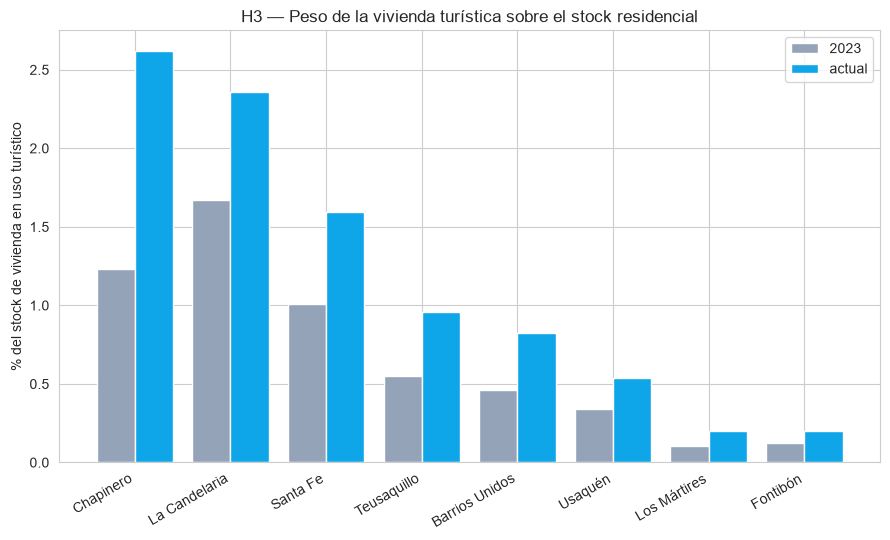

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
top8 = h3.head(8)
x = range(len(top8))
ax.bar([i - 0.2 for i in x], top8["pct_2023"], width=0.4, label="2023", color="#94a3b8")
ax.bar([i + 0.2 for i in x], top8["pct_2025"], width=0.4, label="actual", color="#0ea5e9")
ax.set_xticks(list(x))
ax.set_xticklabels(top8["localidad"], rotation=30, ha="right")
ax.set_ylabel("% del stock de vivienda en uso turístico")
ax.set_title("H3 — Peso de la vivienda turística sobre el stock residencial")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/h3_peso_stock_vivienda.png", dpi=150)
plt.show()

**Lectura:** en Chapinero, la fracción del stock de vivienda en uso turístico prácticamente se **duplicó** en dos años (1.23% → 2.62%), y el mismo patrón de duplicación aparece en Santa Fe, Teusaquillo y Barrios Unidos. Esta es la hipótesis con la evidencia temporal más limpia de las cinco.

## H4 — Relación con el avalúo catastral

**Fuente:** D6 (`avaluo_catastral_ph_manzana_actual.geojson`, 15,593 manzanas con propiedad horizontal, mediana de avalúo por m² — campo `AV_CAT_PH`). Este dataset no trae localidad — se asigna con el mismo cruce espacial *point-in-polygon* (usando el centroide de cada manzana) contra D5. El agregado por localidad se pondera por número de predios (`PREDIOS`) de cada manzana, no un promedio simple, para no darle el mismo peso a una manzana de 5 predios que a una de 800.

In [9]:
avaluo_data = json.load(open(RAW / "avaluo_catastral_ph_manzana_actual.geojson", encoding="utf-8"))
print(f"Manzanas: {len(avaluo_data['features'])}")

filas = []
for f in avaluo_data["features"]:
    p = f["properties"]
    centroide = shape(f["geometry"]).centroid
    localidad = asignar_localidad(centroide, localidad_polys)
    filas.append({"av_cat_ph": p.get("AV_CAT_PH"), "predios": p.get("PREDIOS"), "localidad": localidad})

avaluo_df = pd.DataFrame(filas).dropna(subset=["localidad", "av_cat_ph", "predios"])
avaluo_df["ponderado"] = avaluo_df["av_cat_ph"] * avaluo_df["predios"]
avaluo_df["key"] = avaluo_df["localidad"].apply(normalizar)

avaluo_loc = avaluo_df.groupby("key").apply(
    lambda g: g["ponderado"].sum() / g["predios"].sum(), include_groups=False
).rename("avaluo_ph_m2")

h4 = pd.concat([avaluo_loc, vt_actual_k.rename("vt_actual")], axis=1).dropna()
h4["avaluo_ph_m2"] = h4["avaluo_ph_m2"].round(0).astype(int)
h4 = h4.sort_values("vt_actual", ascending=False)
corr_h4 = h4[["avaluo_ph_m2", "vt_actual"]].corr(method="spearman").iloc[0, 1]
print(f"Correlación de Spearman (avalúo por m² vs. vivienda turística): {corr_h4:.3f}  (n={len(h4)} localidades)")
h4

Manzanas: 15593


Correlación de Spearman (avalúo por m² vs. vivienda turística): 0.674  (n=19 localidades)


,avaluo_ph_m2,vt_actual
CHAPINERO,4869689,2454
USAQUEN,3806455,1370
SANTA FE,5291349,863
TEUSAQUILLO,4402294,756
BARRIOS UNIDOS,3767483,504
SUBA,3182467,380
ENGATIVA,2854561,357
FONTIBON,3298085,309
CANDELARIA,3193030,221
KENNEDY,2502571,94


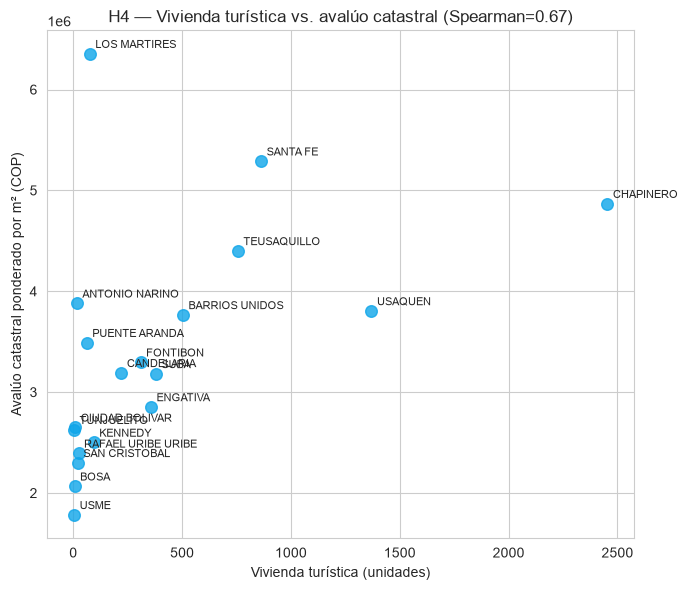

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(h4["vt_actual"], h4["avaluo_ph_m2"], s=70, color="#0ea5e9", alpha=0.8)
for loc, row in h4.iterrows():
    ax.annotate(row.name if isinstance(row.name, str) else loc, (row["vt_actual"], row["avaluo_ph_m2"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Vivienda turística (unidades)")
ax.set_ylabel("Avalúo catastral ponderado por m² (COP)")
ax.set_title(f"H4 — Vivienda turística vs. avalúo catastral (Spearman={corr_h4:.2f})")
plt.tight_layout()
plt.savefig("../outputs/h4_avaluo_catastral.png", dpi=150)
plt.show()

**Lectura:** correlación moderada-fuerte (ρ≈0.67). Las localidades con más vivienda turística sí tienden a tener avalúos por m² más altos, con una excepción notable: **Los Mártires** tiene el avalúo más alto de la ciudad pese a poca vivienda turística — probablemente por su centro comercial/histórico denso, no por turismo. Vale la pena mencionarlo como matiz, no ocultarlo.

**Limitación reconocida:** esta es una foto de un solo año (no hay serie temporal de avalúo cruzada todavía, aunque el dataset sí tiene ediciones anuales 2012-2026 — quedaría como extensión si alcanza el tiempo).

## H5 — Coincidencia con infraestructura turística formal

**Fuentes:** D1 + D7 (`alojamiento_turistico_actual.geojson`) + D8 (`gastronomia_bar_actual.geojson`). Ambos traen código de localidad directo (`LOCALIDAD` / `Nombre_Loc`), igual que D1.

In [11]:
alojamiento = contar_por_codigo_localidad(RAW / "alojamiento_turistico_actual.geojson", "LOCALIDAD").rename("alojamiento_formal")
gastronomia = contar_por_codigo_localidad(RAW / "gastronomia_bar_actual.geojson", "Nombre_Loc").rename("gastronomia_bar")

h5 = pd.concat([vt_actual.rename("vivienda_turistica"), alojamiento, gastronomia], axis=1).fillna(0).astype(int)
h5 = h5.sort_values("vivienda_turistica", ascending=False)
corr_h5 = h5.corr(method="spearman")
print(corr_h5.round(2))
h5

                    vivienda_turistica  alojamiento_formal  gastronomia_bar
vivienda_turistica                1.00                0.86             0.74
alojamiento_formal                0.86                1.00             0.61
gastronomia_bar                   0.74                0.61             1.00


,vivienda_turistica,alojamiento_formal,gastronomia_bar
Chapinero,2454,160,31
Usaquén,1370,64,27
Santa Fe,863,86,7
Teusaquillo,756,209,8
Barrios Unidos,504,33,7
Suba,380,16,25
Engativá,357,45,26
Fontibón,309,75,14
La Candelaria,221,48,3
Kennedy,94,41,10


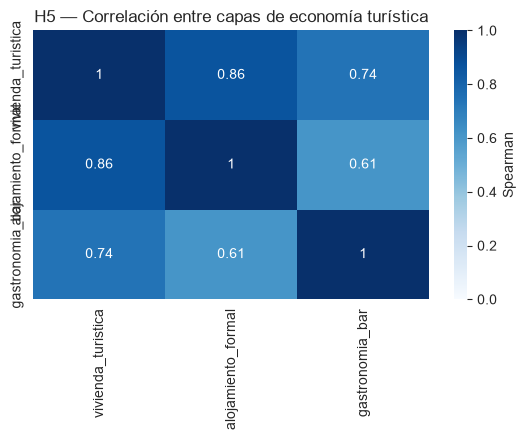

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr_h5, annot=True, cmap="Blues", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Spearman"})
ax.set_title("H5 — Correlación entre capas de economía turística")
plt.tight_layout()
plt.savefig("../outputs/h5_correlacion_clusters.png", dpi=150)
plt.show()

**Lectura:** correlaciones altas (0.86 vivienda turística↔alojamiento formal, 0.74 vivienda turística↔gastronomía) confirman que no es ruido — las tres capas dibujan el mismo clúster de localidades. Matices: Teusaquillo tiene más alojamiento *formal* que Santa Fe pese a menos vivienda turística (perfil más hotelero/negocios); Suba destaca en gastronomía/bar sin liderar en las otras dos (probablemente vida nocturna local, no turismo).

**Advertencia estadística:** las correlaciones de H4 y H5 se calculan sobre ~19 localidades — son patrones descriptivos útiles para un hackathon, no evidencia con significancia estadística robusta. Así debe presentarse.

## H6 — Clusters reales de economía turística vs. planeación (SOM + brecha ZIT)

Las localidades (20) son muy pocas para un mapa auto-organizado. D1/D7/D8 traen el campo `SECCATASTR` (sector catastral, barrio oficial catastral) — una unidad mucho más fina, con **489 sectores** que registran al menos un punto de vivienda turística, alojamiento o gastronomía. Filtrando a sectores con ≥3 puntos en total (para no entrenar con ruido de 1-2 observaciones aisladas) quedan **309 sectores**.

**Diseño en dos pasos, deliberadamente separados:**

1. **Clusters "reales"** — el SOM se entrena *solo* con variables de fenómeno (nunca se le dice dónde está la ZIT), para que agrupe los sectores por cómo se comporta su economía turística, sin sesgo de planeación:
   - **Intensidad** (`intensidad_vt` = log de vivienda turística por sector) — separado a propósito de la mezcla: un sector con 3 puntos 100% vivienda turística no es lo mismo que uno con 300.
   - **Formalidad / mezcla** (`pct_alojamiento_formal`, `pct_gastronomia_bar`, como % de los puntos del sector).
   - **Dinámica** (`crecimiento_pct`, 2023→actual por sector, mismo cálculo que H1 pero a nivel sector).
   - **Precio** (`avaluo_ph_m2`, vía point-in-polygon contra las manzanas de D6 con un índice espacial `STRtree` — indispensable con 15,593 manzanas candidatas).
2. **Estatus ZIT por sector** — se calcula aparte (point-in-polygon contra D2, igual que H2 pero agregado por sector en vez de por localidad) y **no entra a entrenar el SOM**. Se cruza *después* contra los clusters ya formados: la brecha entre "dónde está pasando la turistificación real" y "dónde la planeó el POT" es el hallazgo, no un input del modelo.

**Limitación reconocida:** el stock de vivienda residencial (la variable central de H3) solo existe en D3 a nivel de localidad, no de sector catastral — el eje de "presión sobre vivienda" se queda en crecimiento + avalúo como proxy, no en la métrica exacta de H3.

In [13]:
from shapely import STRtree
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from minisom import MiniSom
import numpy as np

manzana_polys = [shape(f["geometry"]) for f in avaluo_data["features"]]
manzana_valores = [f["properties"]["AV_CAT_PH"] for f in avaluo_data["features"]]
manzana_tree = STRtree(manzana_polys)


def avaluo_por_punto(lon, lat):
    if lon is None or lat is None:
        return None
    idx = manzana_tree.query(Point(lon, lat), predicate="within")
    return manzana_valores[idx[0]] if len(idx) else None


FUENTES_SECTOR = [
    ("vivienda_turistica_actual.geojson", "SECCATASTR", "LATITUD", "LONGITUD", "vivienda_turistica"),
    ("alojamiento_turistico_actual.geojson", "SECCATASTR", "LATITUD", "LONGITUD", "alojamiento_formal"),
    ("gastronomia_bar_actual.geojson", "Sector_Cat", "Latitud", "Longitud", "gastronomia_bar"),
]

filas = []
zit_filas = []  # solo vivienda turistica: dentro/fuera de ZIT, para cruzar DESPUES del clustering
for fname, campo_sector, campo_lat, campo_lon, etiqueta in FUENTES_SECTOR:
    data = json.load(open(RAW / fname, encoding="utf-8"))
    for f in data["features"]:
        p = f["properties"]
        sector = fix_mojibake(p.get(campo_sector))
        if not sector:
            continue
        avaluo = avaluo_por_punto(p.get(campo_lon), p.get(campo_lat))
        filas.append({"sector": sector, "tipo": etiqueta, "avaluo": avaluo})
        if etiqueta == "vivienda_turistica":
            punto_wm = shape(f["geometry"])  # Web Mercator, igual que zit_polys (ver H2)
            dentro = any(poly.contains(punto_wm) for poly in zit_polys)
            zit_filas.append({"sector": sector, "dentro_zit": dentro})

puntos_sector = pd.DataFrame(filas)
conteos = puntos_sector.pivot_table(index="sector", columns="tipo", values="avaluo", aggfunc="size", fill_value=0)
avaluo_sector = puntos_sector.groupby("sector")["avaluo"].mean().rename("avaluo_ph_m2")

# Vivienda turistica 2023, solo para el crecimiento por sector (no entra a los demas calculos)
vt2023_data = json.load(open(RAW / "vivienda_turistica_2023.geojson", encoding="utf-8"))
vt2023_sectores = [
    fix_mojibake(f["properties"].get("Sector_Cat"))
    for f in vt2023_data["features"] if f["properties"].get("Sector_Cat")
]
vt_2023_por_sector = pd.Series(vt2023_sectores).value_counts().rename("vt_2023")

# Estatus ZIT por sector: independiente, NO se usa para entrenar el SOM (celda siguiente)
zit_por_sector = pd.DataFrame(zit_filas).groupby("sector")["dentro_zit"].agg(["sum", "count"])
zit_por_sector = zit_por_sector.rename(columns={"sum": "dentro_zit_n", "count": "n_vt_zit_check"})

perfiles = conteos.join(avaluo_sector)
perfiles["total_puntos"] = conteos.sum(axis=1)
perfiles = perfiles[perfiles["total_puntos"] >= 3].copy()
perfiles["avaluo_ph_m2"] = perfiles["avaluo_ph_m2"].fillna(perfiles["avaluo_ph_m2"].median())

perfiles["vt_2023"] = perfiles.index.map(vt_2023_por_sector).fillna(0)
perfiles["crecimiento_pct"] = (
    (perfiles["vivienda_turistica"] - perfiles["vt_2023"]) / (perfiles["vt_2023"] + 1) * 100
).round(1)
perfiles["pct_vivienda_turistica"] = (perfiles["vivienda_turistica"] / perfiles["total_puntos"] * 100).round(1)
perfiles["pct_alojamiento_formal"] = (perfiles["alojamiento_formal"] / perfiles["total_puntos"] * 100).round(1)
perfiles["pct_gastronomia_bar"] = (perfiles["gastronomia_bar"] / perfiles["total_puntos"] * 100).round(1)
# Intensidad como eje aparte de la mezcla: sin esto, un sector con 3 puntos 100% vivienda
# turistica queda identico a uno con 300 puntos 100% vivienda turistica.
perfiles["intensidad_vt"] = np.log1p(perfiles["vivienda_turistica"])
perfiles["pct_fuera_zit"] = perfiles.index.map(
    (1 - zit_por_sector["dentro_zit_n"] / zit_por_sector["n_vt_zit_check"]) * 100
)

print(f"Sectores con >=3 puntos: {len(perfiles)}  |  con estatus ZIT calculable: {perfiles['pct_fuera_zit'].notna().sum()}")
perfiles.sort_values("total_puntos", ascending=False).head()

Sectores con >=3 puntos: 309  |  con estatus ZIT calculable: 303


,alojamiento_formal,gastronomia_bar,vivienda_turistica,avaluo_ph_m2,total_puntos,vt_2023,crecimiento_pct,pct_vivienda_turistica,pct_alojamiento_formal,pct_gastronomia_bar,intensidad_vt,pct_fuera_zit
sector,,,,,,,,,,,,
CHAPINERO CENTRAL,20,0,766,4.180280e+06,786,245.0,211.8,97.5,2.5,0.0,6.642487,0.130548
VERACRUZ,20,0,362,4.089304e+06,382,179.0,101.7,94.8,5.2,0.0,5.894403,0.000000
CHICO NORTE,27,7,311,6.496217e+06,345,158.0,96.2,90.1,7.8,2.0,5.743003,10.610932
CHICO NORTE III SECTOR,6,2,258,5.550061e+06,266,155.0,66.0,97.0,2.3,0.8,5.556828,89.147287
RINCON DEL CHICO,4,1,197,7.163317e+06,202,120.0,63.6,97.5,2.0,0.5,5.288267,98.984772


In [14]:
FEATURE_COLS = ["intensidad_vt", "pct_alojamiento_formal", "pct_gastronomia_bar", "crecimiento_pct", "avaluo_ph_m2"]
X_scaled = StandardScaler().fit_transform(perfiles[FEATURE_COLS].values)

# Clustering real: directo sobre los 309 sectores. Se probo fusionar los nodos entrenados
# del SOM (81 pesos) en vez de esto, y resulto inestable -- una perturbacion de redondeo de
# 0.1 en un input cambiaba por completo que sectores caian en cada cluster (81 puntos es muy
# poco para que un clustering jerarquico sea robusto). Clusterizar los 309 sectores si es estable.
N_CLUSTERS = 6
perfiles["cluster_id"] = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward").fit_predict(X_scaled)

# El SOM se entrena aparte y solo se usa para la posicion 2D (visualizacion) -- no define clusters.
GRID = 9  # ~5*sqrt(n_sectores) neuronas (regla de Vesanto) -> topologia real, no solo "9 clusters"
som = MiniSom(GRID, GRID, len(FEATURE_COLS), sigma=1.5, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 10000)
perfiles["nodo"] = [som.winner(x) for x in X_scaled]
u_matrix = som.distance_map()  # 0 = nodo parecido a sus vecinos, 1 = frontera entre grupos distintos

print(f"Clusters: {N_CLUSTERS}  |  sectores por nodo SOM (promedio): {len(perfiles) / GRID**2:.1f}")

Clusters: 6  |  sectores por nodo SOM (promedio): 3.8


**Nombrar los clusters** es un paso que el SOM no hace solo (agrupa, no interpreta) — se nombra con una regla explícita aplicada sobre los centroides de los 6 clusters finales (no sobre nodos crudos, para que no dependa de cuál nodo específico de la grilla le toca a cada perfil al entrenar):

1. Si más del 50% de los puntos del cluster son gastronomía/bar → **"Gastronomía / vida local, sin presión turística"** (probablemente vida nocturna del barrio, no turismo — mismo matiz que Suba en H5).
2. Si la proporción de alojamiento formal supera a la de vivienda turística **y** su alojamiento formal está sobre la mediana de los clusters → **"Polo hotelero / negocios"**.
3. De los clusters restantes, el de mayor intensidad (`intensidad_vt`) → **"Núcleo turístico consolidado"**; el segundo → **"Foco turístico emergente"**.
4. Lo que queda → **"Residencial ordinario, sin presión turística"**.

Nota: el avalúo catastral no alcanzó a separar un cluster propio de "residencial de alta renta" en esta corrida — una vez se controla por intensidad/mezcla/crecimiento, el precio no genera una partición adicional a esta resolución (6 clusters). Se deja como observación honesta, no se fuerza la categoría.

In [15]:
REPORT_COLS = FEATURE_COLS + ["pct_vivienda_turistica", "vivienda_turistica"]
resumen_clusters = perfiles.groupby("cluster_id")[REPORT_COLS].mean().round(1)
resumen_clusters["n_sectores"] = perfiles.groupby("cluster_id").size()

aloj_mediana = resumen_clusters["pct_alojamiento_formal"].median()
resumen_clusters["intensidad_rank"] = resumen_clusters["intensidad_vt"].rank(ascending=False)


def nombrar_perfil(row):
    if row["pct_gastronomia_bar"] > 50:
        return "Gastronomía / vida local, sin presión turística"
    if row["pct_alojamiento_formal"] > row["pct_vivienda_turistica"] and row["pct_alojamiento_formal"] > aloj_mediana:
        return "Polo hotelero / negocios"
    if row["intensidad_rank"] == 1:
        return "Núcleo turístico consolidado"
    if row["intensidad_rank"] == 2:
        return "Foco turístico emergente"
    return "Residencial ordinario, sin presión turística"


resumen_clusters["perfil"] = resumen_clusters.apply(nombrar_perfil, axis=1)
perfiles["perfil"] = perfiles["cluster_id"].map(resumen_clusters["perfil"])
resumen_clusters[["n_sectores", "vivienda_turistica", "pct_alojamiento_formal", "pct_gastronomia_bar",
                   "crecimiento_pct", "avaluo_ph_m2", "perfil"]].sort_values("vivienda_turistica", ascending=False)

,n_sectores,vivienda_turistica,pct_alojamiento_formal,pct_gastronomia_bar,crecimiento_pct,avaluo_ph_m2,perfil
cluster_id,,,,,,,
4,9,71.8,12.1,2.3,807.2,4945718.6,Núcleo turístico consolidado
0,118,49.1,8.9,1.4,61.2,4301388.9,Foco turístico emergente
5,33,5.5,6.2,22.9,42.7,3322636.7,"Residencial ordinario, sin presión turística"
3,86,5.3,0.4,0.0,117.3,2978337.7,"Residencial ordinario, sin presión turística"
1,57,4.3,44.0,1.0,79.5,3011816.2,"Residencial ordinario, sin presión turística"
2,6,0.8,0.0,76.4,-31.9,3050625.3,"Gastronomía / vida local, sin presión turística"


## La diferencia: clusters reales vs. estatus ZIT

Los clusters de arriba se formaron **sin usar ZIT para nada**. Ahora sí se cruzan contra el estatus de planeación (dentro/fuera de ZIT) calculado independientemente, ponderando por número de puntos — no promediando el % de cada sector por igual, porque un sector con 1 solo punto de vivienda turística da 0%/100% de golpe y mete puro ruido si pesa igual que uno con 100 puntos.

In [16]:
check_total = zit_por_sector["n_vt_zit_check"].sum()
dentro_total = zit_por_sector["dentro_zit_n"].sum()
baseline_fuera_zit = (1 - dentro_total / check_total) * 100
print(f"Baseline ciudad (ponderado por punto): {baseline_fuera_zit:.1f}% fuera de ZIT (n={check_total} puntos) "
      f"-- consistente con el {h2.loc[h2['corte'] == 'actual', 'pct_fuera_zit'].iloc[0]}% de H2")

zit_counts = zit_por_sector.rename(columns={"dentro_zit_n": "dentro", "n_vt_zit_check": "total"})
con_zit = perfiles.join(zit_counts[["dentro", "total"]]).dropna(subset=["total"])
brecha = con_zit.groupby("perfil")[["dentro", "total"]].sum()
brecha["pct_fuera_zit"] = (1 - brecha["dentro"] / brecha["total"]) * 100
brecha["brecha_vs_ciudad"] = (brecha["pct_fuera_zit"] - baseline_fuera_zit).round(1)
brecha["n_sectores"] = con_zit.groupby("perfil").size()
brecha.sort_values("brecha_vs_ciudad", ascending=False).round(1)

Baseline ciudad (ponderado por punto): 55.3% fuera de ZIT (n=7529 puntos) -- consistente con el 55.3% de H2


,dentro,total,pct_fuera_zit,brecha_vs_ciudad,n_sectores
perfil,,,,,
"Gastronomía / vida local, sin presión turística",0.0,5.0,100.0,44.7,4
"Residencial ordinario, sin presión turística",61.0,886.0,93.1,37.8,172
Núcleo turístico consolidado,295.0,646.0,54.3,-1.0,9
Foco turístico emergente,3000.0,5797.0,48.2,-7.1,118


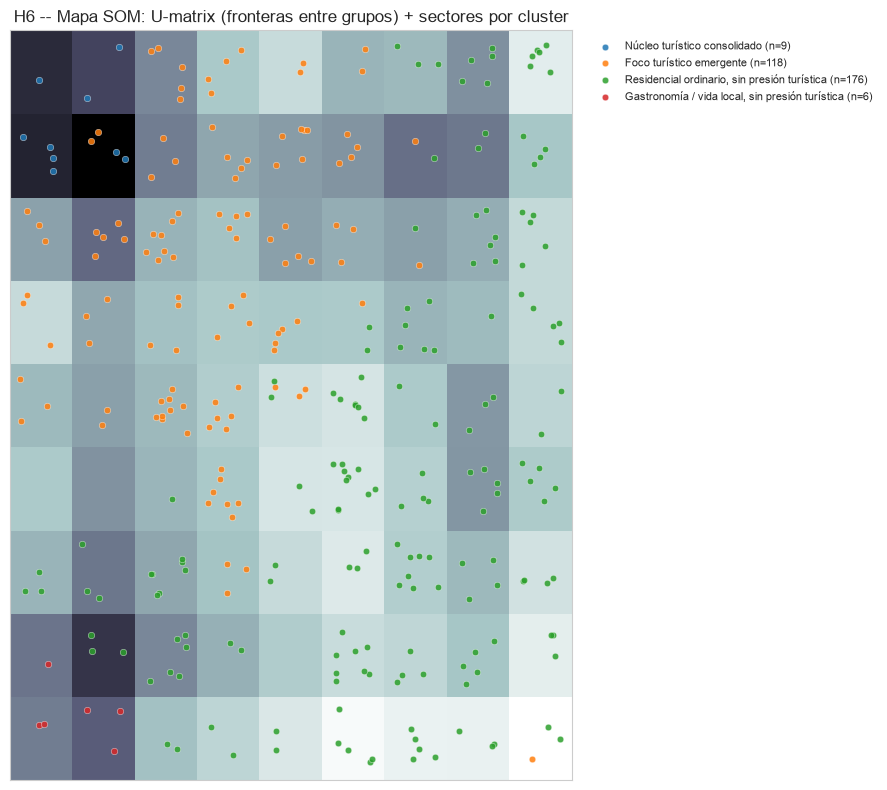

In [17]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.pcolor(u_matrix.T, cmap="bone_r")
perfil_orden = list(dict.fromkeys(resumen_clusters.sort_values("vivienda_turistica", ascending=False)["perfil"]))
palette = plt.cm.tab10.colors
color_map = {p: palette[i % 10] for i, p in enumerate(perfil_orden)}
rng = np.random.default_rng(42)
for perfil in perfil_orden:
    sub = perfiles[perfiles["perfil"] == perfil]
    xs = [r + 0.5 + rng.uniform(-0.35, 0.35) for r, c in sub["nodo"]]
    ys = [c + 0.5 + rng.uniform(-0.35, 0.35) for r, c in sub["nodo"]]
    ax.scatter(xs, ys, s=22, color=color_map[perfil], label=f"{perfil} (n={len(sub)})",
               edgecolor="white", linewidth=0.3, alpha=0.85)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
ax.set_title("H6 -- Mapa SOM: U-matrix (fronteras entre grupos) + sectores por cluster")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("../outputs/h6_mapa_som.png", dpi=150, bbox_inches="tight")
plt.show()

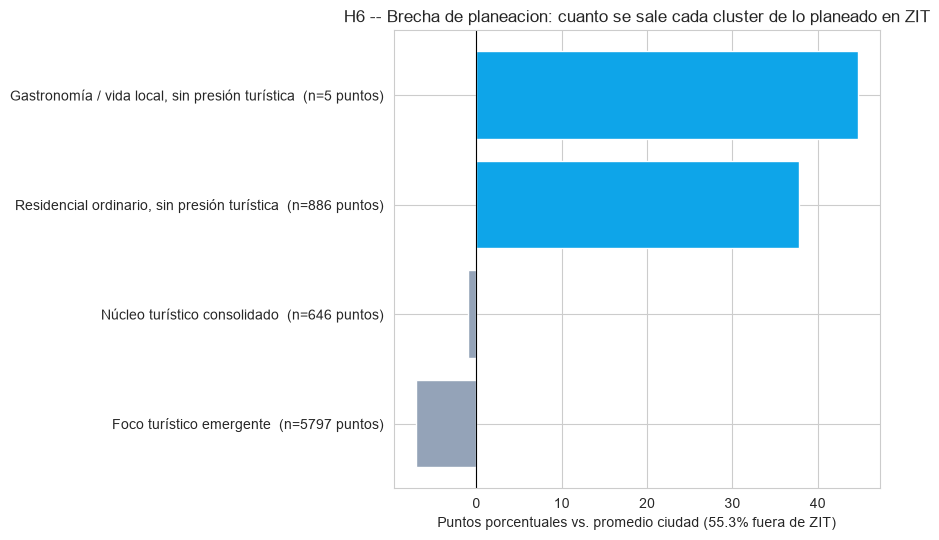

Guardado: data/processed/clusters_sector_catastral.csv (309 sectores)


In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
gap_sorted = brecha.sort_values("brecha_vs_ciudad")
colors = ["#0ea5e9" if v >= 0 else "#94a3b8" for v in gap_sorted["brecha_vs_ciudad"]]
labels = [f"{p}  (n={int(gap_sorted.loc[p, 'total'])} puntos)" for p in gap_sorted.index]
ax.barh(labels, gap_sorted["brecha_vs_ciudad"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Puntos porcentuales vs. promedio ciudad ({baseline_fuera_zit:.1f}% fuera de ZIT)")
ax.set_title("H6 -- Brecha de planeacion: cuanto se sale cada cluster de lo planeado en ZIT")
plt.tight_layout()
plt.savefig("../outputs/h6_brecha_zit.png", dpi=150, bbox_inches="tight")
plt.show()

perfiles_out = perfiles.copy()
perfiles_out["nodo"] = perfiles["nodo"].apply(lambda rc: f"{rc[0]}-{rc[1]}")
perfiles_out.to_csv(PROCESSED / "clusters_sector_catastral.csv")
print(f"Guardado: data/processed/clusters_sector_catastral.csv ({len(perfiles_out)} sectores)")

**Lectura:** el clustering (directo sobre los 309 sectores, no sobre los nodos del SOM — ver nota de la celda de entrenamiento) encuentra 4 perfiles con comportamiento de planeación muy distinto:

| Perfil | Sectores | vivienda turística prom. | Crecimiento | % fuera de ZIT |
|---|---:|---:|---:|---:|
| Núcleo turístico consolidado | 9 | 71.8 | +807% | 54.3% (≈ promedio) |
| Foco turístico emergente | 118 | 49.1 | +61% | 48.2% (ligeramente mejor) |
| Residencial ordinario, sin presión turística | 176 | ~5 | +40-120% según subgrupo | **93.1%** (+37.8 pts) |
| Gastronomía / vida local, sin presión turística | 6 | 0.8 | -32% | 100% (n muy chico, no concluyente) |

El hallazgo central es la brecha, no los clusters por sí solos: los focos ya consolidados o en expansión activa (Núcleo + Foco, 127 sectores) están *dentro* del promedio de planeación de la ciudad — el POT sí los capturó razonablemente. Pero la vivienda turística **dispersa** — la mayoría de los sectores de Bogotá (176 de 309), cada uno con solo un puñado de unidades — está casi totalmente (93.1%) fuera de cualquier ZIT oficial. Es la confirmación, a nivel de sector, de lo que H2 ya insinuaba a nivel de localidad (55.3% fuera de ZIT en promedio): esa cifra promedio esconde que el problema de planeación no está en los polos turísticos ya reconocidos, sino en la vivienda turística de baja intensidad repartida por toda la ciudad, que nunca estuvo en el radar de ninguna zona planeada.

**Matices honestos:**
- El perfil "Gastronomía" tiene solo 4-6 sectores con apenas 3-5 puntos de vivienda turística verificables contra ZIT — no sacar conclusiones fuertes de esa barra, se deja por transparencia, no porque sea un hallazgo robusto.
- "Residencial ordinario" agrupa 3 subclusters con composición distinta (uno con ~44% de alojamiento formal, otro casi sin infraestructura formal, otro con más gastronomía) que quedaron bajo el mismo nombre por simplicidad narrativa — el detalle completo por `cluster_id` está en el CSV exportado.
- El avalúo catastral no alcanzó a separar un cluster propio de "residencial de alta renta, sin turismo" en esta resolución (6 clusters) — una vez se controla por intensidad/mezcla/crecimiento, el precio no aportó una partición adicional. Se deja como observación, no se fuerza la categoría.
- La cifra base de "55.3% fuera de ZIT" se validó cruzando contra el cálculo original de H2 sobre *todos* los puntos de la ciudad (sin filtrar por sector) — coincide exactamente, lo que confirma que la lógica de cruce espacial es consistente entre ambas hipótesis.

**Salida para el dashboard:** `data/processed/clusters_sector_catastral.csv` — sector, features, posición en el mapa SOM (`nodo`), `cluster_id` y `perfil`, listos para colorear un mapa. Falta el polígono de cada sector catastral (no incluido en las fuentes usadas aquí) para un choropleth real — por ahora el CSV solo tiene el nombre del sector.

## Síntesis — tabla consolidada por localidad

In [19]:
LOC_KEY_TO_NAME = {normalizar(nombre): nombre for nombre in LOC_CODE_TO_NAME.values()}

h1_k = h1.copy(); h1_k.index = h1_k.index.map(normalizar)
h5_k = h5.copy(); h5_k.index = h5_k.index.map(normalizar)
# h3 y h4 ya están indexados por clave normalizada (vienen del cruce con D3/D6)

resumen = pd.concat([
    h1_k[["vt_2023", "vt_actual", "crecimiento_pct"]],
    h3[["pct_2025"]].rename(columns={"pct_2025": "pct_stock_vivienda"}),
], axis=1)
resumen = resumen.join(h4["avaluo_ph_m2"], how="left").join(h5_k[["alojamiento_formal", "gastronomia_bar"]], how="left")
resumen.insert(0, "localidad", [LOC_KEY_TO_NAME.get(k, k) for k in resumen.index])
resumen = resumen.sort_values("vt_actual", ascending=False).reset_index(drop=True)
resumen.to_csv(PROCESSED / "turismo_vivienda_resumen_localidad.csv", index=False)
resumen

,localidad,vt_2023,vt_actual,crecimiento_pct,pct_stock_vivienda,avaluo_ph_m2,alojamiento_formal,gastronomia_bar
0,Chapinero,1128.0,2454.0,117.6,2.619,4869689.0,160.0,31.0
1,Usaquén,837.0,1370.0,63.7,0.537,3806455.0,64.0,27.0
2,Santa Fe,521.0,863.0,65.6,1.595,5291349.0,86.0,7.0
3,Teusaquillo,423.0,756.0,78.7,0.955,4402294.0,209.0,8.0
4,Barrios Unidos,274.0,504.0,83.9,0.823,3767483.0,33.0,7.0
5,Suba,322.0,380.0,18.0,0.076,3182467.0,16.0,25.0
6,Engativá,225.0,357.0,58.7,0.113,2854561.0,45.0,26.0
7,Fontibón,187.0,309.0,65.2,0.200,3298085.0,75.0,14.0
8,La Candelaria,154.0,221.0,43.5,2.357,3193030.0,48.0,3.0
9,Kennedy,82.0,94.0,14.6,0.023,2502571.0,41.0,10.0


## Conclusiones preliminares

1. **H1 — confirmada.** La vivienda turística creció 76% en dos años, concentrada en Chapinero (+118%), Usaquén, Santa Fe, Teusaquillo y Barrios Unidos.
2. **H2 — parcialmente confirmada, con matiz importante.** La mayoría (55.3%) sigue fuera de las ZIT oficiales, pero esa proporción bajó respecto a 2023 (61.1%): el crecimiento reciente se concentró más dentro de las zonas planeadas, no fuera.
3. **H3 — confirmada, la más sólida.** En Chapinero el peso sobre el stock de vivienda se duplicó en dos años (1.23%→2.62%); mismo patrón en Santa Fe y Teusaquillo.
4. **H4 — confirmada con matiz.** Correlación moderada-fuerte (ρ≈0.67) con el avalúo catastral por m², con Los Mártires como outlier explicable.
5. **H5 — confirmada.** Fuertes correlaciones (0.86 y 0.74) con alojamiento formal y gastronomía — es un clúster real de economía turística, no ruido estadístico.
6. **H6 — confirmada, con el hallazgo más accionable del análisis.** Clusterizando los 309 sectores catastrales por intensidad, formalidad, crecimiento y precio (sin usar ZIT para nada), y cruzando después contra el estatus de planeación: los focos turísticos ya consolidados o emergentes (127 sectores) están dentro del promedio de planeación de la ciudad, pero la vivienda turística dispersa de baja intensidad — la mayoría de los sectores de Bogotá (176) — está 93.1% fuera de toda ZIT oficial, muy por encima del 55.3% promedio. El SOM se usó para visualizar cómo se relacionan esos perfiles en un mapa 2D, no para definir los clusters (ver nota metodológica en H6 sobre por qué eso resultó inestable).

## Próximos pasos (si el equipo decide avanzar con este tema)

- Repetir H2/H4 con más cortes temporales (D6 tiene ediciones anuales 2012-2026; D1 solo tiene 2022/2023/actual).
- Construir el visor/dashboard final (mapa coroplético por localidad, con capas conmutables por hipótesis).
- Redactar el formulario de caracterización y la nota técnica de integración de datos, documentando explícitamente el problema de formato de D5 (Esri JSON etiquetado como GeoJSON) y el tamaño de muestra reducido (~19 localidades) en H4/H5.
- Diligenciar `requirements.txt` en la raíz del repo (ya incluye `shapely`, `odfpy`, `openpyxl`, `minisom`, `scikit-learn`, usados aquí).
- Conseguir los polígonos de sector catastral (no incluidos en las fuentes usadas aquí) para pasar el mapa SOM abstracto de H6 a un choropleth real sobre el mapa de Bogotá.
